## **Формирование dataset-а и EDA**

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.stats.diagnostic as diag

Подгрузим дату, с которой будем в дальнейшем работать - по золоту и биткоину

In [102]:
gold = pd.read_csv("Gold Price.csv")
bitcoin = pd.read_csv("bitcoin_price_dataset_2015_2023.csv")

In [103]:
gold

,Date,Price,Open,High,Low,Volume,Chg%
0,2024-11-06,77030,78300,78570,77030,0,-1.86
1,2024-11-05,78490,78224,78670,78160,0,0.11
2,2024-11-04,78401,78498,78642,78237,0,-0.54
3,2024-11-01,78829,78650,78887,78550,0,0.64
4,2024-10-31,78326,79264,79999,77803,90,-1.17
...,...,...,...,...,...,...,...
2801,2014-01-06,29119,29300,29395,29051,24380,-0.55
2802,2014-01-04,29279,29279,29279,29279,0,-1.51
2803,2014-01-03,29727,30031,30125,29539,3050,-0.83
2804,2014-01-02,29975,29678,30050,29678,3140,1.47


In [104]:
bitcoin

,Date,Open Price (USD),High Price (USD),Low Price (USD),Closing Price (USD),Adjusted Closing Price (USD),Trading Volume
0,2023-09-06,25772.601563,25845.994141,25708.595703,25721.945313,25721.945313,10252755968
1,2023-09-05,25814.957031,25858.375000,25589.988281,25779.982422,25779.982422,11094740040
2,2023-09-04,25968.169922,26081.525391,25657.025391,25812.416016,25812.416016,10680635106
3,2023-09-03,25869.472656,26087.148438,25817.031250,25969.566406,25969.566406,8962524523
4,2023-09-02,25800.910156,25970.285156,25753.093750,25868.798828,25868.798828,10100387473
...,...,...,...,...,...,...,...
3166,2015-01-05,265.084015,278.341003,265.084015,274.473999,274.473999,43962800
3167,2015-01-04,281.145996,287.230011,257.612000,264.195007,264.195007,55629100
3168,2015-01-03,314.846008,315.149994,281.082001,281.082001,281.082001,33054400
3169,2015-01-02,314.079010,315.838989,313.565002,315.032013,315.032013,7860650


Объединим два датаскта по общим датам (так как в данных по биткоину были дополнительные дни - выходные, мы решили их убрать, оставив только будние дни, когда работала биржа)

In [105]:
df = pd.merge(gold, bitcoin, on="Date", how="inner")
df

,Date,Price,Open,High,Low,Volume,Chg%,Open Price (USD),High Price (USD),Low Price (USD),Closing Price (USD),Adjusted Closing Price (USD),Trading Volume
0,2023-09-06,59111,59208,59310,59021,6940,-0.32,25772.601563,25845.994141,25708.595703,25721.945313,25721.945313,10252755968
1,2023-09-05,59301,59550,59550,59150,30,-0.14,25814.957031,25858.375000,25589.988281,25779.982422,25779.982422,11094740040
2,2023-09-04,59385,59125,59540,59101,90,0.47,25968.169922,26081.525391,25657.025391,25812.416016,25812.416016,10680635106
3,2023-09-01,59106,59082,59507,59051,400,-0.01,25934.021484,26125.869141,25362.609375,25800.724609,25800.724609,17202862221
4,2023-08-31,59113,59138,59379,59001,200,-0.01,27301.929688,27456.078125,25752.929688,25931.472656,25931.472656,20181001451
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2233,2015-01-07,27159,27328,27350,27110,19660,-0.83,286.076996,298.753998,283.079010,294.337006,294.337006,24866800
2234,2015-01-06,27385,27095,27442,27094,26640,2.00,274.610992,287.553009,272.696014,286.188995,286.188995,23245700
2235,2015-01-05,26847,26800,26911,26650,570,0.55,265.084015,278.341003,265.084015,274.473999,274.473999,43962800
2236,2015-01-02,26700,26585,26740,26285,1990,0.43,314.079010,315.838989,313.565002,315.032013,315.032013,7860650


Далее переименуем столбцы для удобства работы с данными, оставив при этом только необходимые параметры. Например, скорректированную цену закрытия мы убрали, поскольку в дальнейшем будем ориентироваться на финальную цену закрытия активов. Также округлим некоторые значения, так как точность информации при округлении до 0/2 знаков после запятой сократится, но незначительно. То есть на финальные выводы это повлияет слабо. В конце также добавим процентное изменение цены биткоина (переменную CHG%_BTC) для оценки изменения его доходности. Первое значение CHG%_BTC (от 2015-01-01) взяли с банка, использовавшегося для парсинга исходных таблиц

In [106]:
df.drop(columns=['Adjusted Closing Price (USD)'], inplace=True)
df.columns = ['Date', 'FCP_Gold', 'OP_Gold', 'HP_Gold', 'LP_Gold','TV_Gold',
              'CHG%_Gold', 'OP_BTC', 'HP_BTC', 'LP_BTC', 'FCP_BTC','TV_BTC']

In [107]:
df[['OP_BTC', 'HP_BTC', 'LP_BTC', 'FCP_BTC']] = df[['OP_BTC', 'HP_BTC', 'LP_BTC', 'FCP_BTC']].round(0).astype(int)
df['CHG%_BTC'] = ((df['FCP_BTC'] - df['FCP_BTC'].shift(-1)) / df['FCP_BTC'].shift(-1) * 100).round(2)
df.insert(4, 'FCP_Gold', df.pop('FCP_Gold'))
df.loc[2237,'CHG%_BTC'] = -1.90
df

,Date,OP_Gold,HP_Gold,LP_Gold,FCP_Gold,TV_Gold,CHG%_Gold,OP_BTC,HP_BTC,LP_BTC,FCP_BTC,TV_BTC,CHG%_BTC
0,2023-09-06,59208,59310,59021,59111,6940,-0.32,25773,25846,25709,25722,10252755968,-0.22
1,2023-09-05,59550,59550,59150,59301,30,-0.14,25815,25858,25590,25780,11094740040,-0.12
2,2023-09-04,59125,59540,59101,59385,90,0.47,25968,26082,25657,25812,10680635106,0.04
3,2023-09-01,59082,59507,59051,59106,400,-0.01,25934,26126,25363,25801,17202862221,-0.50
4,2023-08-31,59138,59379,59001,59113,200,-0.01,27302,27456,25753,25931,20181001451,-5.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2233,2015-01-07,27328,27350,27110,27159,19660,-0.83,286,299,283,294,24866800,2.80
2234,2015-01-06,27095,27442,27094,27385,26640,2.00,275,288,273,286,23245700,4.38
2235,2015-01-05,26800,26911,26650,26847,570,0.55,265,278,265,274,43962800,-13.02
2236,2015-01-02,26585,26740,26285,26700,1990,0.43,314,316,314,315,7860650,0.32


Таким образом мы получили следующие количественные переменные:

* `OP_BTC` — open price Bitcoin                
* `OP_Gold` — open price Gold      

* `HP_BTC` — highest price Bitcoin                
* `HP_Gold` — highest price Gold         

* `LP_BTC` — lowest price Bitcoin                
* `LP_Gold` — lowest price Gold                       
                
* `FCP_BTC` — final closing price Bitcoin                
* `FCP_Gold` — final closing price Gold                
                
* `TV_BTC` — trading volume Bitcoin                
* `TV_Gold` — trading volume Gold                
                
* `CHG%_BTC` — % price change of Bitcoin                
* `CHG%_Gold` — % price change of gold                 
                
**Gold = price per 10gr**

**Все параметры в $ (USD)**

Проверим сформированные параметры и переменные на пропуски и дублирующиеся значения

In [108]:
print(f'Количество пропусков в df: {df.isnull().sum().sum()}')
print(f'Количество дублей в df: {df.duplicated().sum()}')

Количество пропусков в df: 0
Количество дублей в df: 0


Так как пропусков данных в основной рабочей таблицы нет, можно не заполнять их медианными/средними и иными значениями

In [109]:
df.describe()

,OP_Gold,HP_Gold,LP_Gold,FCP_Gold,TV_Gold,CHG%_Gold,OP_BTC,HP_BTC,LP_BTC,FCP_BTC,TV_BTC,CHG%_BTC
count,2238.000000,2238.000000,2238.000000,2238.000000,2238.000000,2238.000000,2238.000000,2238.000000,2238.000000,2238.000000,2.238000e+03,2238.000000
mean,38653.550492,38857.650581,38442.591600,38650.211796,12930.209115,0.039035,14331.951743,14702.324397,13921.485702,14335.179178,1.803433e+10,0.294584
std,10817.185529,10878.552995,10750.090447,10815.822719,11291.755937,0.806080,16089.757456,16522.476688,15591.650944,16076.162320,2.055511e+10,4.420609
min,24583.000000,24635.000000,24470.000000,24545.000000,0.000000,-5.610000,177.000000,212.000000,172.000000,178.000000,7.860650e+06,-37.160000
25%,29319.500000,29456.750000,29192.500000,29340.000000,6315.000000,-0.380000,1049.250000,1079.250000,1031.000000,1055.750000,2.645232e+08,-1.477500
50%,32635.500000,32800.000000,32480.500000,32591.500000,10610.000000,0.040000,8223.500000,8393.500000,8003.000000,8230.000000,1.363268e+10,0.195000
75%,48752.500000,49032.000000,48500.250000,48804.250000,16785.000000,0.460000,22211.250000,22667.750000,21435.500000,22220.750000,2.988738e+10,2.127500
max,61899.000000,61899.000000,61150.000000,61683.000000,106920.000000,5.300000,67550.000000,68790.000000,66382.000000,67567.000000,3.509679e+11,25.240000


По общим статистическим данным можно заметить, что, например, в среднем биткоин рос в финальной цене закрытия на 0,29%, в то время как золото - только на 0.04%. Это доказывает более высокую волатильность биткоина как актива. Это же можно отметить и по std CHG%. У биткоина стандартное отклонение около 4.4 изменении цен каждый день, а у золота - менее единицы, то есть около 0,8

## **Визуализация**

Сделаем несколько визуализаций найденных данных для поиска интересных закономерностей и дальнейшего формулирования гипотез. Заметим, что в этом разделе применяется библиотека plotly, которая не отображается на старых версиях Юпитера и в принципе на Гитхабе. Поэтому рекомендуем смотреть эту часть на nbviewer.org, чтобы поиграться с интерактивными графиками $:)$


In [110]:
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'notebook'

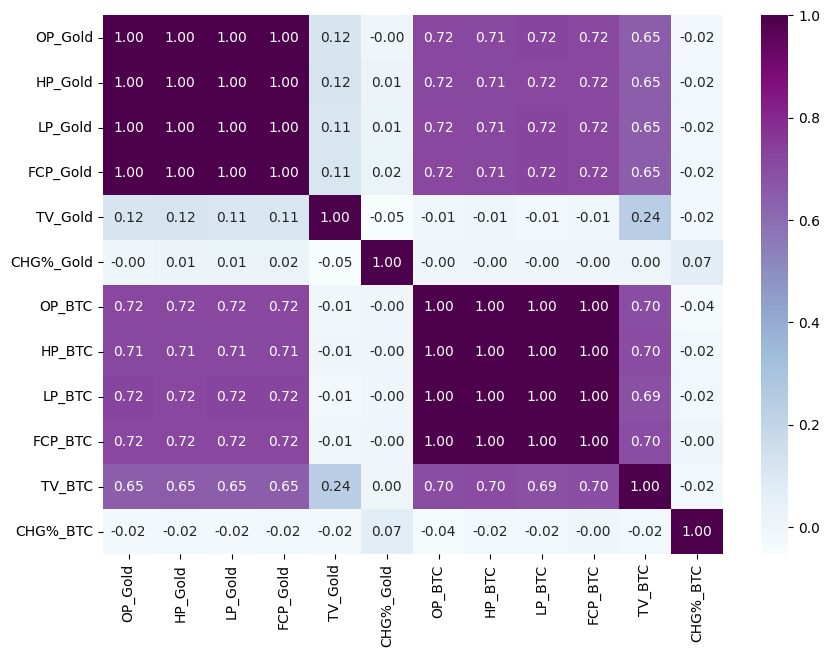

In [111]:
df_corr = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 7))
ax = sns.heatmap(df_corr, cmap="BuPu", annot=True, fmt="0.2f")
plt.show()

Интересно, что между основными показателями биткоина и золота есть умеренная положительная корреляция от ${0,65}$ до ${0,72}$. Можно исследовать это в следующем этапе проекта

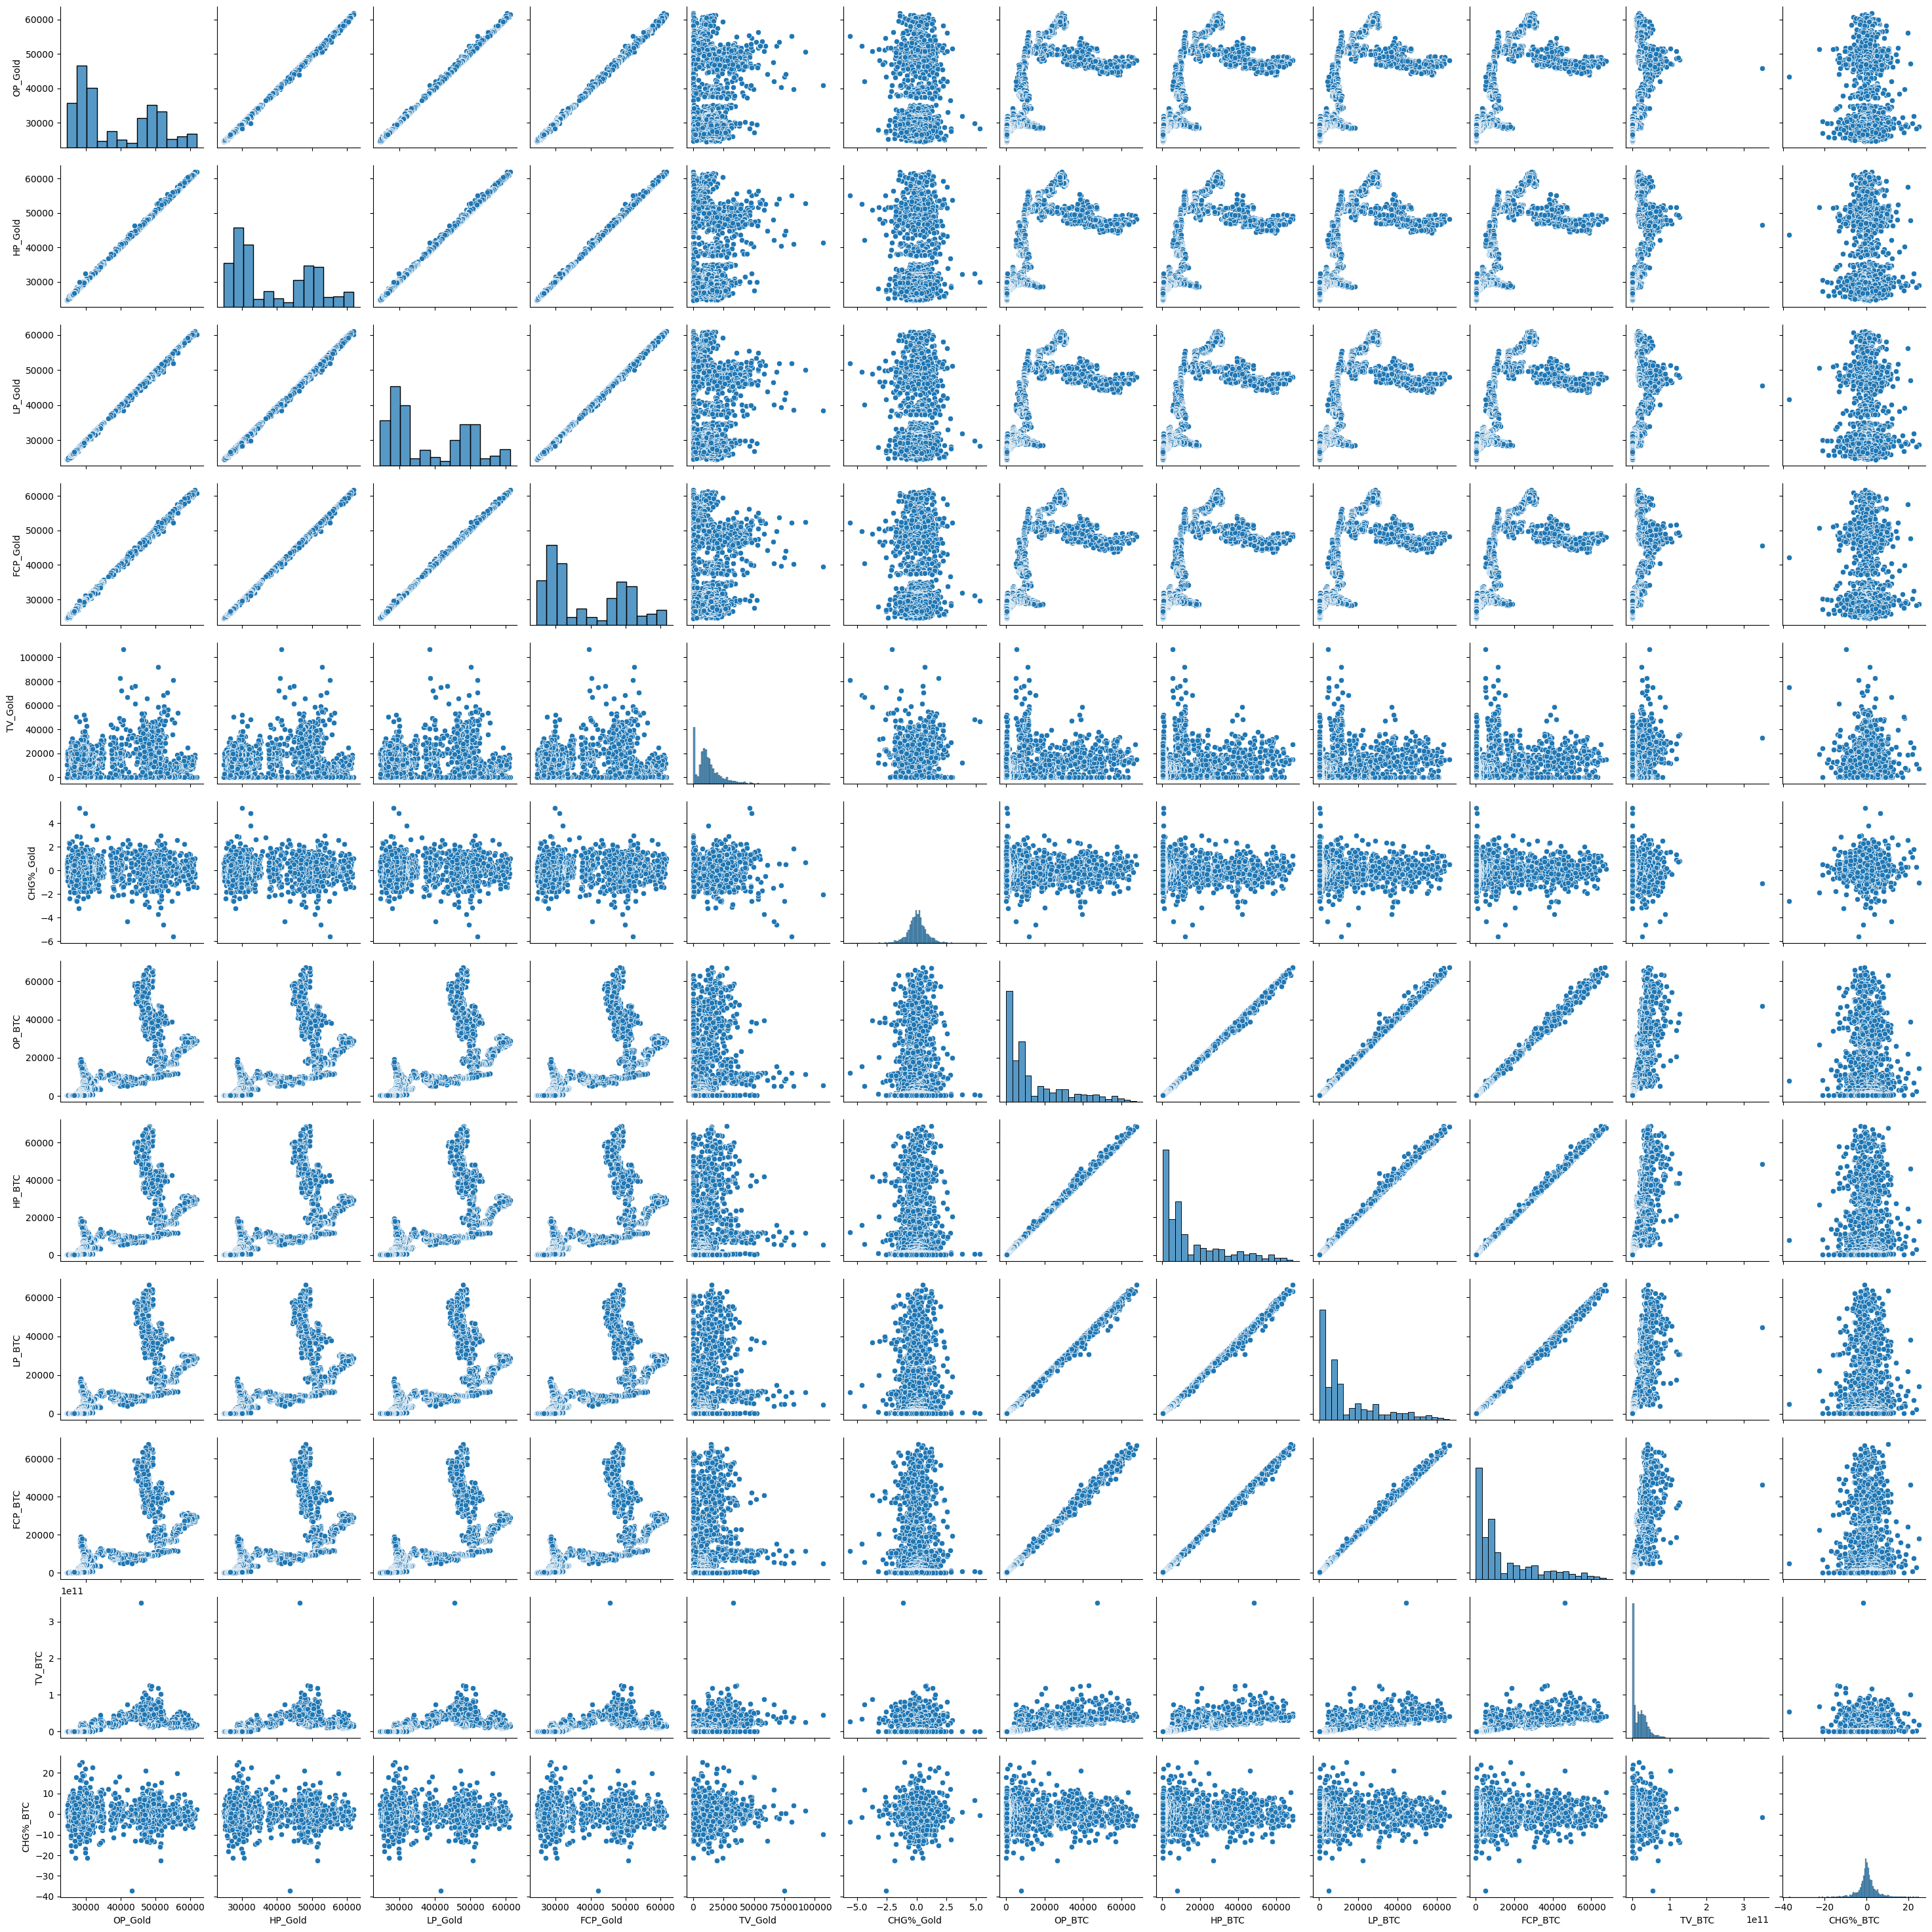

In [112]:
plt.show(sns.pairplot(df))

Наглядная визуализация зависимости переменных, которая потом позволит перейти к анализу доходностей выбранных для проекта активов

In [113]:
trace_0 = go.Scatter(x=df['Date'], y=df['HP_Gold'], name='Gold')
trace_1 = go.Scatter(x=df['Date'], y=df['HP_BTC'], name='Bitcoin')
layout = go.Layout(title='Highest prices', xaxis_title='Date', yaxis_title='Highest price')
fig_1 = go.Figure(data=[trace_0,trace_1], layout=layout)

fig_1.show()

In [114]:
trace_2 = go.Scatter(x=df['Date'], y=df['LP_Gold'], name='Gold')
trace_3 = go.Scatter(x=df['Date'], y=df['LP_BTC'], name='Bitcoin')
layout = go.Layout(title='Lowest prices', xaxis_title='Date', yaxis_title='Lowest price')
fig_2 = go.Figure(data=[trace_2,trace_3], layout=layout)

fig_2.show()

Также построим распределение золота и биткоина по общему объему на торгах в день за выбранный период. В целом, биткоин использовался для покупки и продажи больше, скорее всего в силу большей актуальности, цифровизации и цене

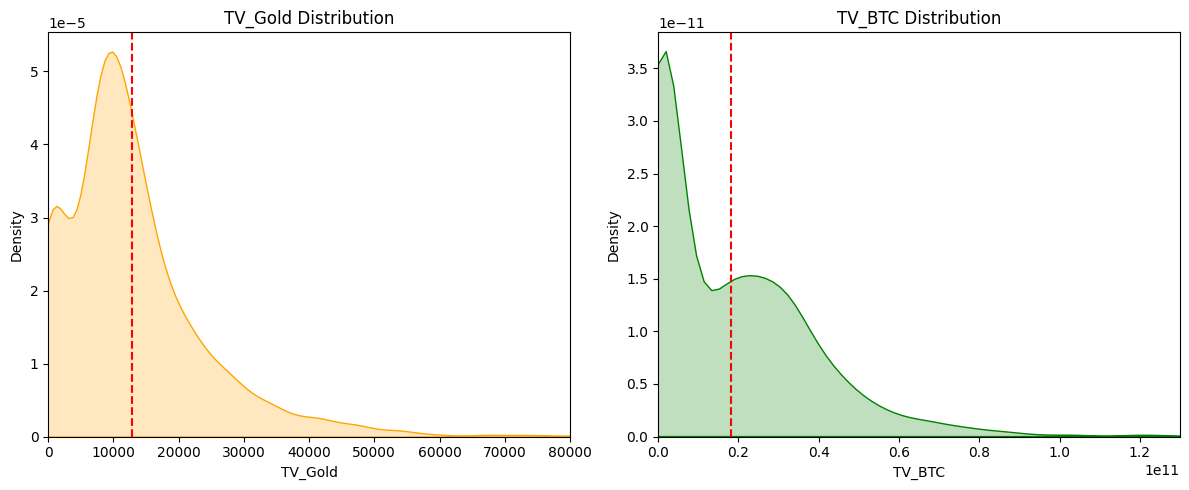

In [115]:
fig,axes = plt.subplots(1, 2, figsize=(12, 5))

sns.kdeplot(data=df, x='TV_Gold', color='orange', fill=True, ax=axes[0])
axes[0].axvline(df.TV_Gold.mean(), linestyle='--', color='r')
axes[0].set_xlim(0, 80000)
axes[0].set_title("TV_Gold Distribution")

sns.kdeplot(data=df, x='TV_BTC', color='green', fill=True, ax=axes[1])
axes[1].axvline(df.TV_BTC.mean(), linestyle='--', color='r')
axes[1].set_xlim(0, 1.3*(10**11))
axes[1].set_title("TV_BTC Distribution")

plt.tight_layout()
plt.show()

## **Гипотезы**

По окончании небольшого разведочного анализа мы сформулировали следующие гипотезы (будем ориентироваться на доходности активов):

1) Доходности золота и бикоина - независимые сами по себе вектора (т.е. независимы в рамках своего вектора величин) на уровне значимости $5\%$;

2) Золото и биткоин зависят друг от друга в доходностях;

3) Доходность биткоина статистически выше доходности золота на уровне значимости $5\%$

## **Проверка независимости доходностей (в рамках одного вектора)**

Для проверки независимости будем использовать тест Ljung-Box

### Золото

$H_0$: CHG%_Gold распределены независимо

$H_1$: CHG%_Gold не распределены независимо, они демонстрируют автокорреляцию

In [116]:
# проверим автокорелляцию у доходностей золота
alpha = 0.05 # уровень значимости

chg_gold = df['CHG%_Gold']

lb_test_gold = diag.acorr_ljungbox(chg_gold, boxpierce=False, auto_lag=True) # проверка на автокорреляцию
lb_test_gold['lb_pvalue'] > alpha

,lb_pvalue
1,True


$\text{P-value}> 0.05$ для всех лагов (тут auto_lag предлагает посмотреть для 1), значит нет статистически значимой автокорреляции

$H_0$ верна, процентные изменения цены (доходности) золота независимы между собой

Попробуем также посмотреть это на графике независимости лагов

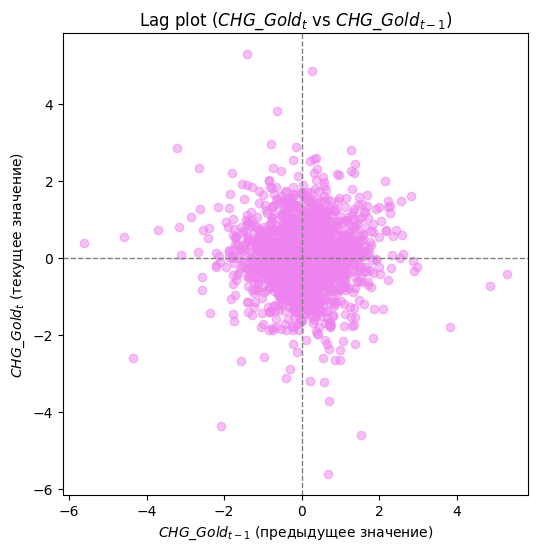

In [117]:
df_chg_t_1_gold = pd.DataFrame({'CHG_Gold_t': chg_gold, 'CHG_Gold_t-1': np.roll(chg_gold, 1)})

plt.figure(figsize=(6, 6))
plt.scatter(df_chg_t_1_gold['CHG_Gold_t-1'][1:], df_chg_t_1_gold['CHG_Gold_t'][1:], alpha=0.5, color='violet')
plt.xlabel('$CHG\_Gold_{t-1}$ (предыдущее значение)')
plt.ylabel('$CHG\_Gold_t$ (текущее значение)')
plt.title('Lag plot ($CHG\_Gold_t$ vs $CHG\_Gold_{t-1}$)')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.show()

Точки не образуют четкой линии, автокорреляция отсутствует

### Биткоин

$H_0$: CHG%_BTC распределены независимо

$H_1$: CHG%_BTC не распределены независимо, они демонстрируют автокорреляцию

In [118]:
# проверим автокорелляцию у доходностей биткоина
chg_btc = df['CHG%_BTC']

lb_test_btc = diag.acorr_ljungbox(chg_btc, boxpierce=False, auto_lag=True) # проверка на автокорреляцию
lb_test_btc['lb_pvalue'] > alpha

,lb_pvalue
1,True
2,True


$\text{P-value}> 0.05$ для всех лагов (здесь уже auto_lag предлагает посмотреть для 2), значит нет статистически значимой автокорреляции

$H_0$ верна, процентные изменения цены (доходности) биткоина независимы между собой

Попробуем также посмотреть это на графике независимости лагов

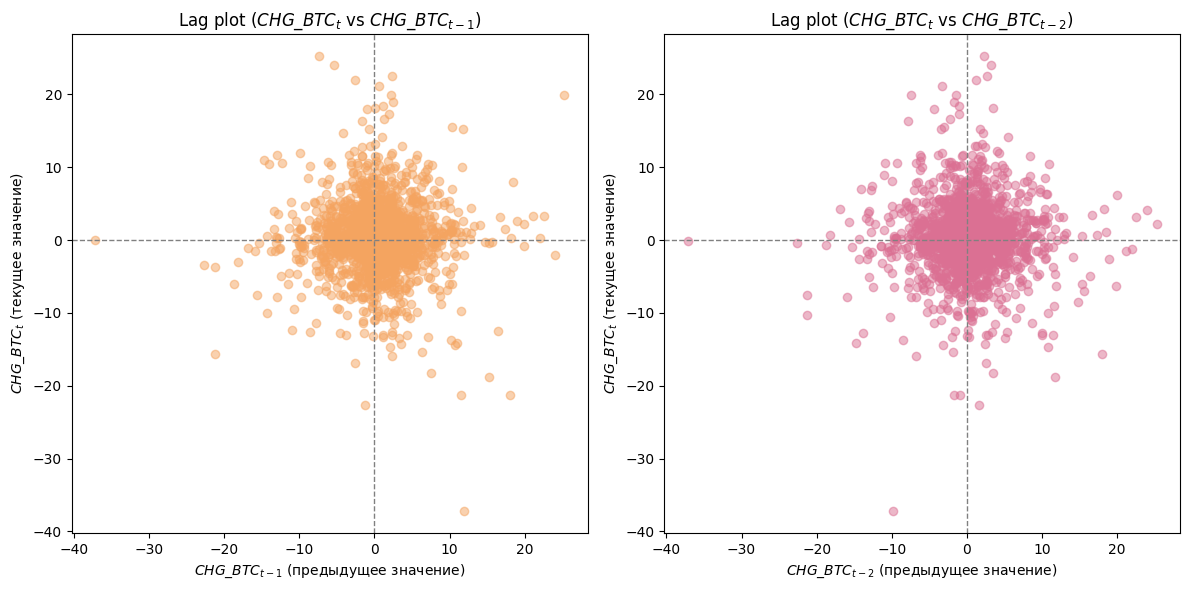

In [119]:
df_chg_t_1_btc = pd.DataFrame({'CHG_BTC_t': chg_btc, 'CHG_BTC_t-1': np.roll(chg_btc, 1)})
df_chg_t_2_btc = pd.DataFrame({'CHG_BTC_t': chg_btc, 'CHG_BTC_t-2': np.roll(chg_btc, 2)})

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].scatter(df_chg_t_1_btc['CHG_BTC_t-1'][1:], df_chg_t_1_btc['CHG_BTC_t'][1:], alpha=0.5, color='sandybrown')
axes[0].set_xlabel('$CHG\_BTC_{t-1}$ (предыдущее значение)')
axes[0].set_ylabel('$CHG\_BTC_t$ (текущее значение)')
axes[0].set_title('Lag plot ($CHG\_BTC_t$ vs $CHG\_BTC_{t-1}$)')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].axvline(0, color='gray', linestyle='--', linewidth=1)

axes[1].scatter(df_chg_t_2_btc['CHG_BTC_t-2'][2:], df_chg_t_2_btc['CHG_BTC_t'][2:], alpha=0.5, color='palevioletred')
axes[1].set_xlabel('$CHG\_BTC_{t-2}$ (предыдущее значение)')
axes[1].set_ylabel('$CHG\_BTC_t$ (текущее значение)')
axes[1].set_title('Lag plot ($CHG\_BTC_t$ vs $CHG\_BTC_{t-2}$)')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].axvline(0, color='gray', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

Точки не образуют четкой линии, автокорреляция отсутствует

Далее будем считать, что доходности золота iid и доходности биткоина также iid, что в дальнейшем сильно упростит исследование данных

## **Проверка независимости доходностей (между векторами)**

Для начала посчитаем корреляцию между величинами (доходности золота и биткоина)

In [120]:
round(df['CHG%_Gold'].corr(df['CHG%_BTC']),5)

np.float64(0.06963)

Более того, покажем, что доходности обоих активов имеют нормальное распределение, но с разными параметрами

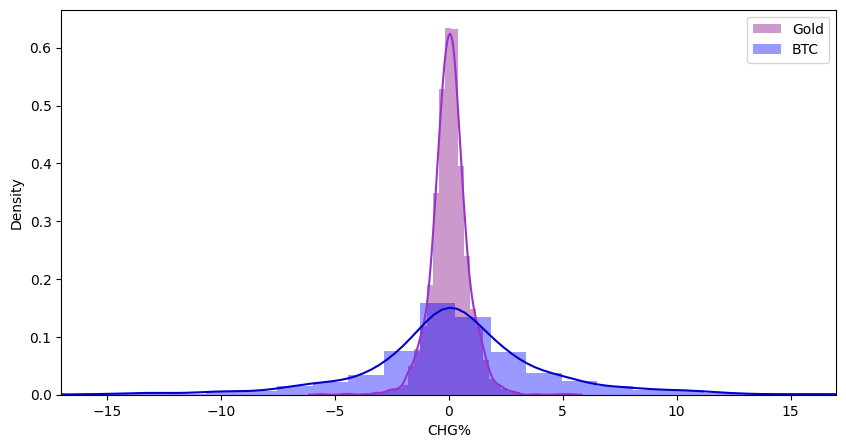

In [121]:
x = df['CHG%_Gold']
y = df['CHG%_BTC']

plt.figure(figsize=(10,5))
plt.hist(x, bins=40, density=True, alpha=0.4, color='purple', label='Gold')
sns.kdeplot(data=x, color='darkorchid')
plt.hist(y, bins=40, density=True, alpha=0.4, color='b', label='BTC')
sns.kdeplot(data=y, color='mediumblue')
plt.legend()
plt.xlabel('CHG%')
plt.xlim(-17,17)
plt.show()

Получается, мы имеем на руках несколько фактов: 1) обе величины распределены нормально, но с разными параметрами и 2) величины имеют корреляцию, близкую к нулю. Однако проверим величины на независимость. Ведь если обе величины не имеют совместного нормального распределения, то даже выясненные нами факты не позволят сделать достоверный вывод о независимости двух векторов между собой

Для это самой проверки независимости двух векторов будем использовать распределение $χ
2$

Сформулируем 2 гипотезы:

$H_0$: Вектора доходностей золота и биткоина НЕзависимы между собой на уровне значимости $5\%$

$H_1$: Вектора доходностей золота и биткоина зависимы между собой $5\%$

In [122]:
from scipy.stats import chi2_contingency

alpha = 0.05
chi2, p, dof, expected = chi2_contingency(pd.crosstab(x,y,margins=False))

if p < alpha:
  print('Отвергаем гипотезу H0 на уровне значимости 5%. Значит, вектора доходностей золота и биткоина зависимы между собой')
else:
  print('Не отвергаем гипотезу H0 на уровне значимости 5%. Значит, вектора доходностей золота и биткоина НЕзависимы между собой')
print("Teststatistic = {}".format(round(chi2)))
print("p-value = {}".format(round(p, 70)))

Отвергаем гипотезу H0 на уровне значимости 5%. Значит, вектора доходностей золота и биткоина зависимы между собой
Teststatistic = 446939
p-value = 5.368e-67


Таким образом, мы выяснили важную деталь: несмотря на очень слабую корреляцию между доходностями золота и биткоина, у величин все-таки есть зависимость. А это значит, что золото и биткоин хоть и несильно коррелируют, но влияют друг на друга в доходностях

## **Бутстрэп**

Для бутстрэпа важно проверить наличие серьезных выбросов по исследуемым параметрам. Для этого построим ящики с усами, наглядно это иллюстрирующих

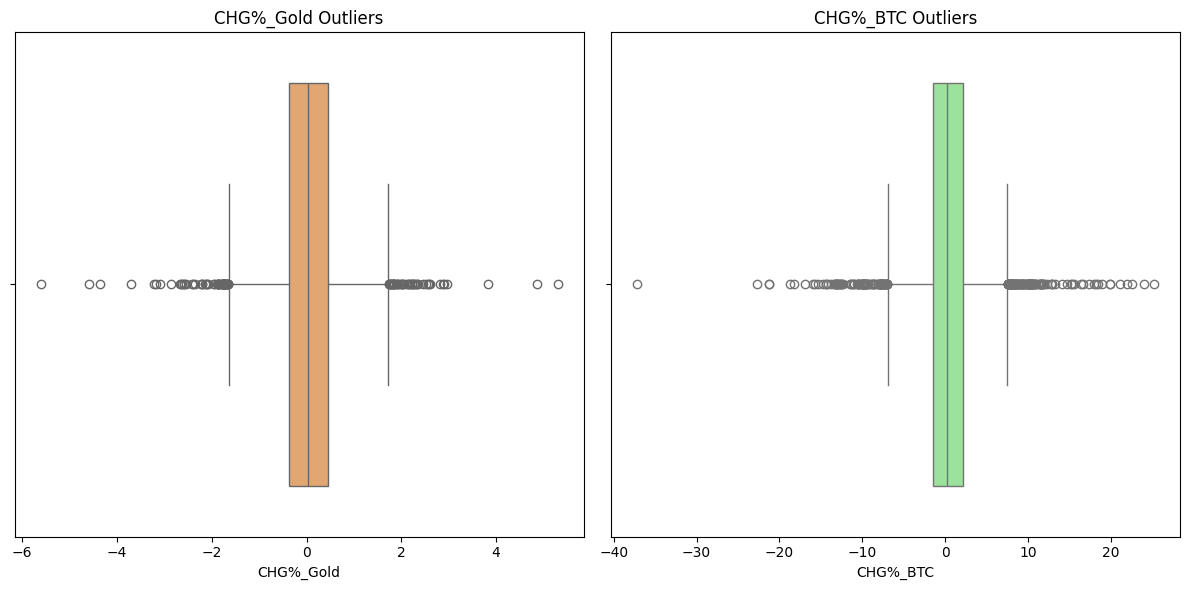

In [123]:
fig,axes = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(data=df, x='CHG%_Gold', color='sandybrown', fill=True, ax=axes[0])
axes[0].set_title("CHG%_Gold Outliers")

sns.boxplot(data=df, x='CHG%_BTC', color='lightgreen', fill=True, ax=axes[1])
axes[1].set_title("CHG%_BTC Outliers")

plt.tight_layout()
plt.show()

Получается, доходности золота и биткоина имееют значительные выбросы, которые нужно убрать для дальнейшего анализа

In [124]:
from matplotlib.cbook import boxplot_stats

low_whisker_Gold = boxplot_stats(df['CHG%_Gold'])[0]['whislo']
high_whisker_Gold = boxplot_stats(df['CHG%_Gold'])[0]['whishi']

low_whisker_BTC = boxplot_stats(df['CHG%_BTC'])[0]['whislo']
high_whisker_BTC = boxplot_stats(df['CHG%_BTC'])[0]['whishi']

df2 = df[(low_whisker_Gold <= df['CHG%_Gold']) & (df['CHG%_Gold'] <= high_whisker_Gold) &
        (low_whisker_BTC <= df['CHG%_BTC']) & (df['CHG%_BTC'] <= high_whisker_BTC)]

x = df2['CHG%_Gold']
y = df2['CHG%_BTC']

Теперь проверим, отличаются ли средние доходности золота и биткоина статистически значимо на уровне значимости $5\%$

$H_0$: Доходность биткоина статистически выше, чем доходность золота

$H_1$: Доходность биткоина статистически не выше, чем доходность золота

In [125]:
def get_bootstrap_sample(x, B_sample=1):
    N = x.size
    sample = np.random.choice(x, size=(N, B_sample), replace=True)

    if B_sample == 1:
        sample = sample.T[0]
    return sample

Оба распределения симметричные, значит можно использовать Эфронов интервал

In [126]:
x_boot = get_bootstrap_sample(x, B_sample=10**4)
x_boot = np.mean(x_boot, axis=0)

y_boot = get_bootstrap_sample(y, B_sample=10**4)
y_boot = np.mean(y_boot, axis=0)

In [127]:
def stat_intervals(boot, alpha=0.05):
    left = np.quantile(boot, alpha/2)
    right = np.quantile(boot, 1-alpha/2)
    return left, right

stat_intervals(x_boot - y_boot)

(np.float64(-0.2724173521850909), np.float64(-0.02423508997429295))

Ноль не попадает в доверительный интервал, то есть на уровне значимости $5\%$ разница есть

Весь интервал отрицательный, значит биткоин в среднем приносит больше доходности, чем золото

Значит, гипотеза о том, что в среднем биткоин - более доходный актив, чем золото, не отвергается на уровне значимости $5\%$

# МО

Попробуем создать модель, которая будет предсказывать процентное изменение  биткоина `CHG%_BTC` на следующий день

In [128]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

Разобьем данные без выбросов на `test` и `train`, возьмем test равный 20% от основной даты

In [129]:
test_size = int(len(df2) * 0.2)
test = df2[:test_size]
train = df2[test_size:]
features = ["CHG%_Gold", "OP_BTC", "HP_BTC", "LP_BTC", "TV_BTC", "OP_Gold", "HP_Gold", "LP_Gold", "FCP_Gold", "FCP_BTC"]

target = 'CHG%_BTC'

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

### Линейная регрессия

In [130]:
model = LinearRegression()
model.fit(X_train, y_train)

# Предсказание
y_pred = model.predict(X_test)
y_pred1 = model.predict(X_train)
# Оценка качества модели на test
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# Оценка качества модели на train
mae1 = mean_absolute_error(y_train, y_pred1)
rmse1 = np.sqrt(mean_squared_error(y_train, y_pred1))
print(f"test: \n MAE: {mae}, RMSE: {rmse} \ntrain: \n MAE: {mae1}, RMSE: {rmse1}")

test: 
 MAE: 0.828452546178593, RMSE: 1.2085324575862928 
train: 
 MAE: 1.6151969119098135, RMSE: 2.2170702736033996


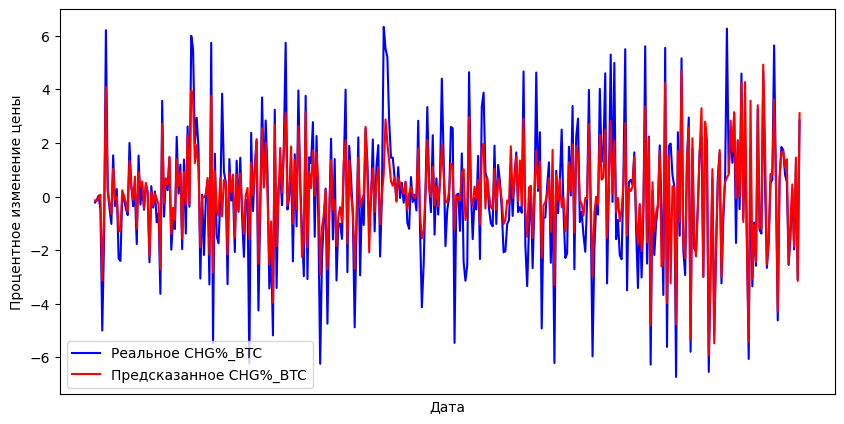

In [131]:
plt.figure(figsize=(10, 5))
plt.plot(test["Date"], y_test, label="Реальное CHG%_BTC", color='blue')
plt.plot(test["Date"], y_pred, label="Предсказанное CHG%_BTC", color='red')
plt.xlabel("Дата")
plt.ylabel("Процентное изменение цены")
plt.xticks([])
plt.legend()
plt.show()

In [132]:
def plot_builder(y_test, y_train, y_pred_test, y_pred_train):
    plt.scatter(y_test, y_pred_test, color="violet", alpha=0.5, label='Предсказания')
    plt.xlabel('Истинные значения')
    plt.ylabel('Предсказанные значения')
    plt.title(f'График истинных и предсказанных значений\nмодели  на тестовой выборке', fontsize=10)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)],
             color='black', label='Идеальная линия')
    plt.legend()

    plt.tight_layout()
    plt.show()

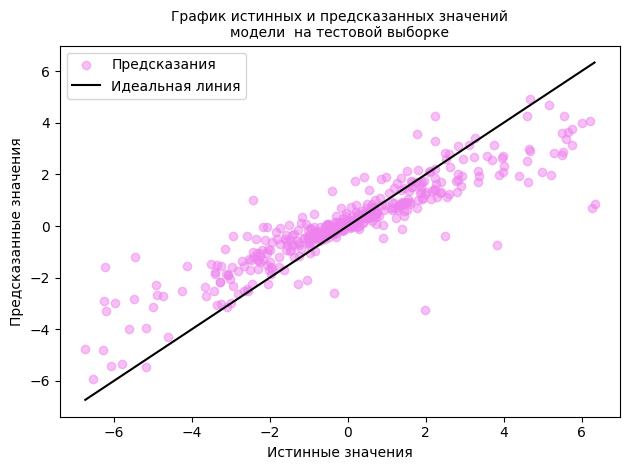

In [133]:
plot_builder(y_test, y_train, y_pred, y_pred1)

### Random Forest

In [134]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Лучшие параметры:", random_search.best_params_)
best_model = random_search.best_params_

Лучшие параметры: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 20}


In [135]:
model = RandomForestRegressor(**best_model)
model.fit(X_train, y_train)

# Делаем предсказания
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

# Оцениваем качество модели на test
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# Оцениваем качество модели на train
mae1 = mean_absolute_error(y_train, y_pred_train)
rmse1 = np.sqrt(mean_squared_error(y_train, y_pred_train))

print(f"test: \n MAE: {mae}, RMSE: {rmse} \ntrain: \n MAE: {mae1}, RMSE: {rmse1}")

test: 
 MAE: 2.1110553818955284, RMSE: 2.7239528106356774 
train: 
 MAE: 1.2431538412900345, RMSE: 1.6990304031706993


Ошибки вышли большие, на наших данных линейная регрессия показала лучший результат, это могло произойти изз того, что
линейная регрессия работает лучше, когда зависимость линейная, а случайный лес лучше для сложных, нелинейных зависимостей

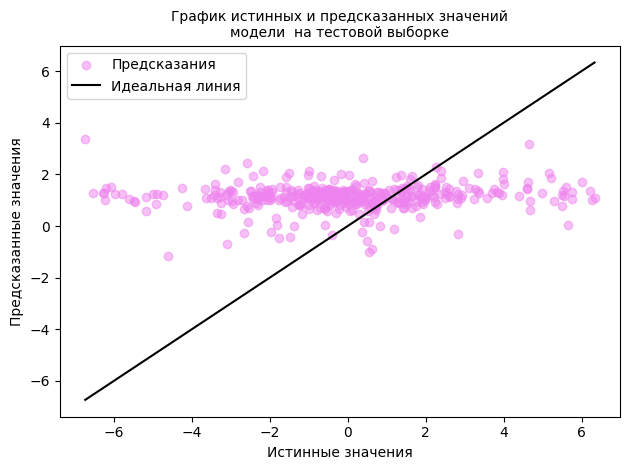

In [136]:
plot_builder(y_test, y_train, y_pred, y_pred_train)

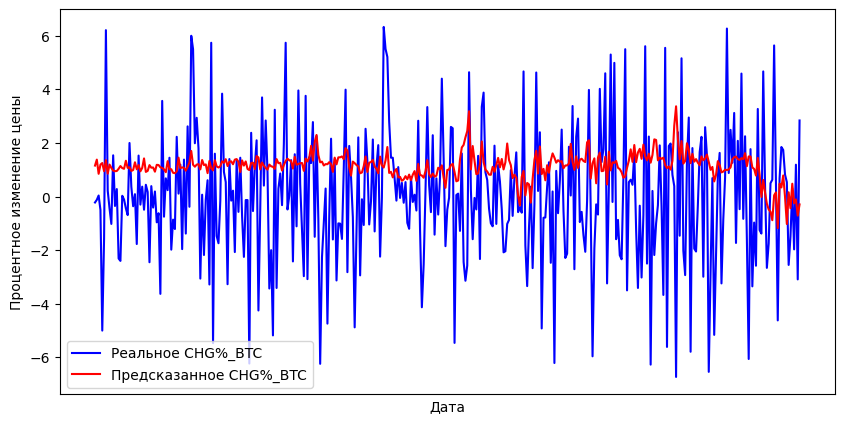

In [137]:
plt.figure(figsize=(10, 5))
plt.plot(test["Date"], y_test, label="Реальное CHG%_BTC", color='blue')
plt.plot(test["Date"], y_pred, label="Предсказанное CHG%_BTC", color='red')
plt.xlabel("Дата")
plt.ylabel("Процентное изменение цены")
plt.xticks([])
plt.legend()
plt.show()